In [12]:
from joblib import load


bestModelPath = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/model/adult/20250513_Eyeclose_SingleFeat_balancedUnseen/bandpower/Random Forest_NoFeatureSelection/model_fold_3.pkl"
model = load(bestModelPath)

frequency_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
channels = [
    'Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 'Fp2',
    'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz', 'Pz'
]

feature_labels = [f"{band}_{ch}" for band in frequency_bands for ch in channels]

Plotting data saved to: plot_data_for_external_tools.csv
Contains 25 features ready for external plotting tools


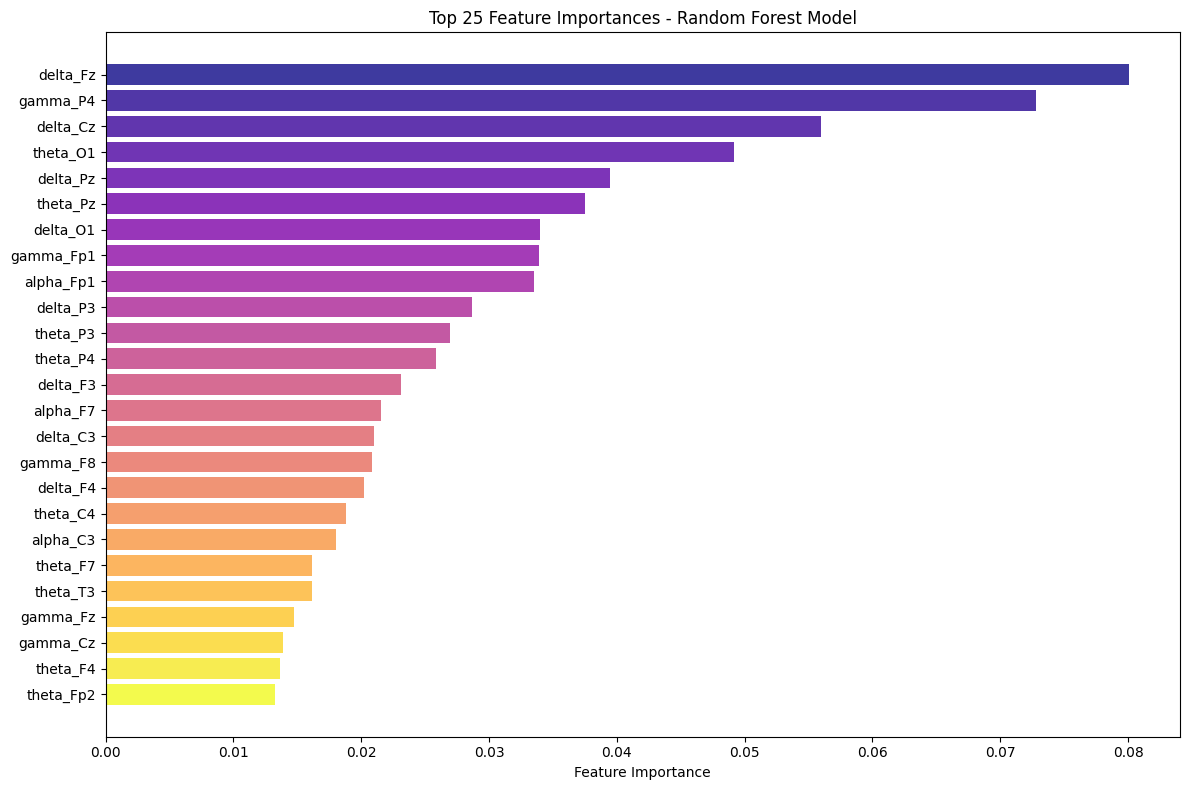

Top 10 Most Important Features:
----------------------------------------
 1. delta_Fz       : 0.0801
 2. gamma_P4       : 0.0728
 3. delta_Cz       : 0.0559
 4. theta_O1       : 0.0492
 5. delta_Pz       : 0.0395
 6. theta_Pz       : 0.0375
 7. delta_O1       : 0.0340
 8. gamma_Fp1      : 0.0339
 9. alpha_Fp1      : 0.0335
10. delta_P3       : 0.0287


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract feature importances from the model
feature_importances = model.feature_importances_

# Create a DataFrame for easier manipulation
importance_df = pd.DataFrame({
    'feature': feature_labels,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Plot feature importance with gradient colors
plt.figure(figsize=(12, 8))
top_n = 25  # Show top 50 features
top_features = importance_df.head(top_n)

# Save plotting data to CSV for use in other tools
plot_data = pd.DataFrame({
    'feature_label': top_features['feature'].values,
    'bar_value': top_features['importance'].values,
    'rank_position': range(len(top_features))  # 0 to 49 for plotting position
})

csv_filename = 'plot_data_for_external_tools.csv'
plot_data.to_csv(csv_filename, index=False)
print(f"Plotting data saved to: {csv_filename}")
print(f"Contains {len(plot_data)} features ready for external plotting tools")

# Create gradient colors from bright yellow (highest importance) to dark purple/pink (lowest importance)
colors = plt.cm.plasma(np.linspace(0, 1, len(top_features)))

bars = plt.barh(range(len(top_features)), top_features['importance'], color=colors)

# Add gradient effect to each bar
for i, bar in enumerate(bars):
    # Create a gradient effect within each bar
    bar.set_alpha(0.8)

plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances - Random Forest Model')
plt.gca().invert_yaxis()  # To have the most important feature at the top

plt.tight_layout()
plt.show()

# Print top 10 features with their importance values
print("Top 10 Most Important Features:")
print("-" * 40)
for i, (feature, importance) in enumerate(top_features.head(10)[['feature', 'importance']].values):
    print(f"{i+1:2d}. {feature:15s}: {importance:.4f}")

In [ ]:
# RETRAIN

In [10]:
# Feature importance statistics
print("Feature Importance Statistics:")
print("=" * 40)
print(f"Total number of features: {len(feature_importances)}")
print(f"Sum of all feature importances: {feature_importances.sum():.6f}")
print(f"Maximum feature importance: {feature_importances.max():.6f}")
print(f"Minimum feature importance: {feature_importances.min():.6f}")
print(f"Mean feature importance: {feature_importances.mean():.6f}")
print(f"Standard deviation: {feature_importances.std():.6f}")
print()
print("Unit: Unitless (relative proportion of impurity reduction)")
print("Interpretation: Each value represents the percentage contribution")
print("of that feature to the model's predictive power.")

Feature Importance Statistics:
Total number of features: 95
Sum of all feature importances: 1.000000
Maximum feature importance: 0.670406
Minimum feature importance: 0.000000
Mean feature importance: 0.010526
Standard deviation: 0.070440

Unit: Unitless (relative proportion of impurity reduction)
Interpretation: Each value represents the percentage contribution
of that feature to the model's predictive power.


In [ ]:
# Save feature importance data to CSV
csv_data = pd.DataFrame({
    'feature_label': importance_df['feature'],
    'importance_value': importance_df['importance'],
    'rank': range(1, len(importance_df) + 1)
})

# Save to CSV file
csv_filename = 'feature_importance_data.csv'
csv_data.to_csv(csv_filename, index=False)

print(f"Feature importance data saved to: {csv_filename}")
print(f"Total features saved: {len(csv_data)}")
print("\nFirst 10 rows of saved data:")
print(csv_data.head(10))

Loading bandpower data...
Found 4 data files
Loaded /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/30s_epochbased/bandpower/bandpower_HC_unseen.npy: shape (14, 5, 20)
Loaded /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/30s_epochbased/bandpower/bandpower_ASD.npy: shape (180, 5, 20)
Loaded /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/30s_epochbased/bandpower/bandpower_HC.npy: shape (58, 5, 20)
Loaded /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/30s_epochbased/bandpower/bandpower_ASD_unseen.npy: shape (30, 5, 20)
Loaded data shape: (282, 100)
Labels shape: (282,)
Unique labels: (array(['ASD', 'HC'], dtype='<U3'), array([210,  72]))

Top 25 features:
 1. delta_Fz
 2. gamma_P4
 3. delta_Cz
 4. theta_O1
 5. delta_Pz
 6. theta_Pz
 7. delta_O1
 8. gamma_Fp1
 9. alpha_Fp1
10. delta_P3
11. theta_P3
12. theta_P4
13. delta_F3
14. alpha_F7
15. delta_C3
16. gamma_F8
17. d

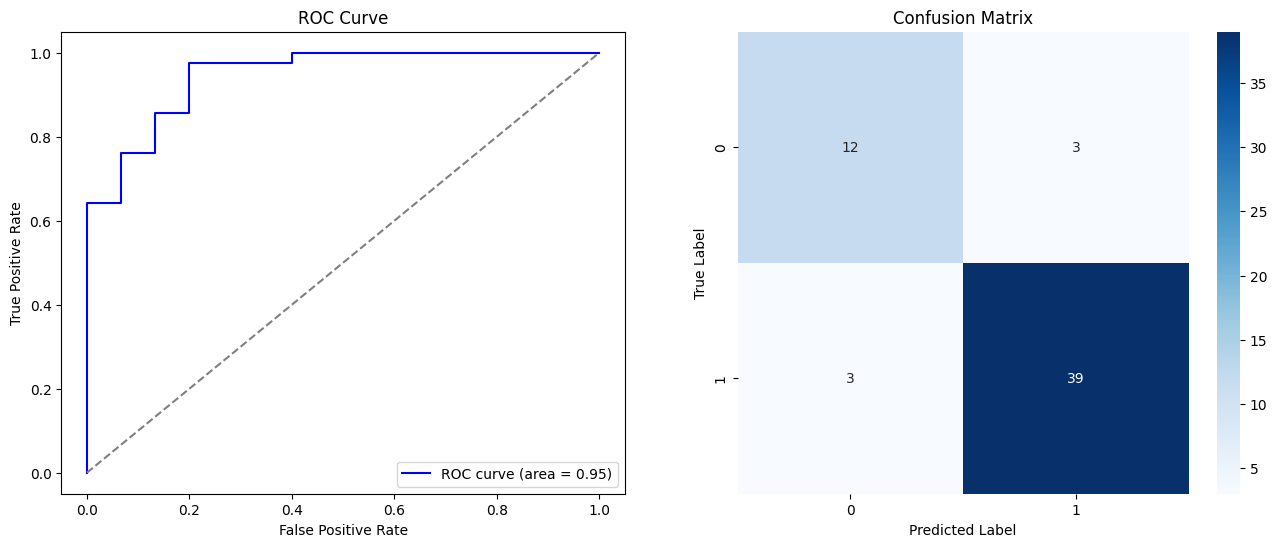

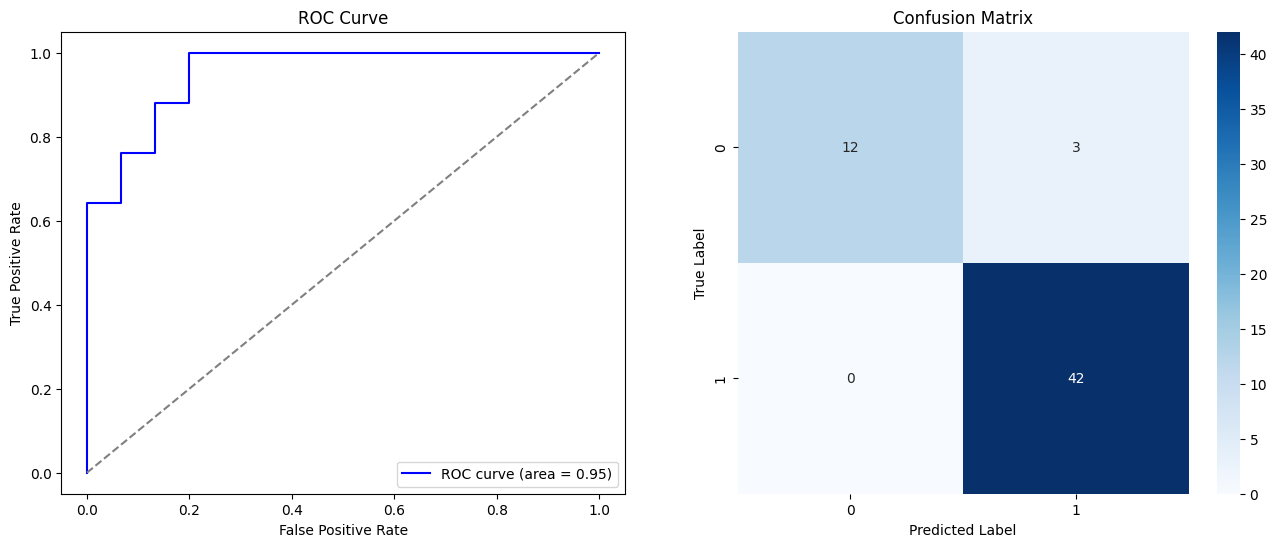

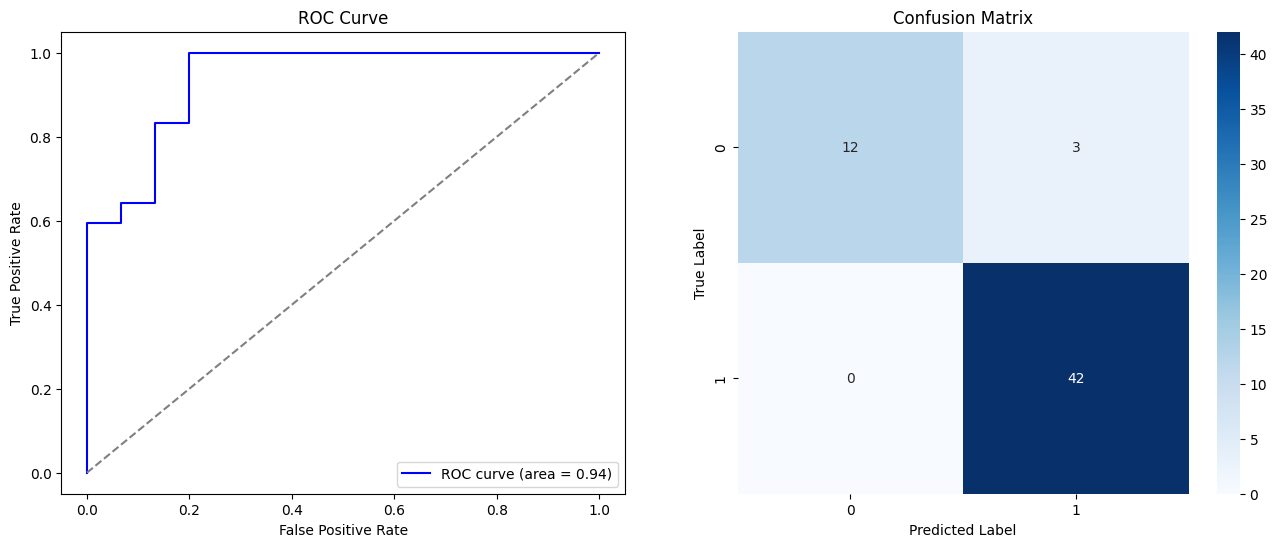

In [22]:
import os
import numpy as np
import joblib
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Settings
IS_HYPERPARAM_TUNING = True
data_path = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/30s_epochbased/bandpower"
whichDirForModelPath = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/model/retrain_adult_bp_EC"
whichFeatureType = "bandpower"

frequency_bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
channels = [
    'Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 'Fp2',
    'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz', 'Pz'
]

def load_data_from_path(data_path):
    """Load bandpower data from the specified path"""
    X_data = []
    y_data = []
    
    # Look for .npy files in the directory
    file_pattern = os.path.join(data_path, "*.npy")
    files = glob.glob(file_pattern)
    
    if not files:
        print(f"No .npy files found in {data_path}")
        # Alternative: look for subdirectories with subject data
        asd_pattern = os.path.join(data_path, "*ASD*.npy")
        hc_pattern = os.path.join(data_path, "*HC*.npy")
        
        asd_files = glob.glob(asd_pattern)
        hc_files = glob.glob(hc_pattern)
        
        if asd_files or hc_files:
            files = asd_files + hc_files
        else:
            print("Checking for subdirectories...")
            # Look in subdirectories
            for root, dirs, filenames in os.walk(data_path):
                for filename in filenames:
                    if filename.endswith('.npy'):
                        files.append(os.path.join(root, filename))
    
    print(f"Found {len(files)} data files")
    
    for file_path in files:
        try:
            # Load the data
            data = np.load(file_path)
            print(f"Loaded {file_path}: shape {data.shape}")
            
            # Determine label from filename
            filename = os.path.basename(file_path)
            if 'ASD' in filename.upper():
                label = 'ASD'
            elif 'HC' in filename.upper():
                label = 'HC'
            else:
                # Try to infer from path or use default
                if 'asd' in file_path.lower():
                    label = 'ASD'
                elif 'hc' in file_path.lower() or 'control' in file_path.lower():
                    label = 'HC'
                else:
                    print(f"Cannot determine label for {filename}, skipping...")
                    continue
            
            # Reshape data to (epochs, features)
            if len(data.shape) == 3:  # (epochs, freq_bands, channels)
                epochs, freq_bands, channels = data.shape
                # Flatten to (epochs, freq_bands * channels)
                data_reshaped = data.reshape(epochs, -1)
            elif len(data.shape) == 2:  # Already (epochs, features)
                data_reshaped = data
            else:
                print(f"Unexpected data shape {data.shape} for {filename}")
                continue
            
            # Add to dataset
            X_data.append(data_reshaped)
            y_data.extend([label] * data_reshaped.shape[0])
            
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    if X_data:
        X = np.vstack(X_data)
        y = np.array(y_data)
        return X, y
    else:
        print("No data loaded successfully")
        return None, None

# Load the data
print("Loading bandpower data...")
X_full, y_full = load_data_from_path(data_path)

if X_full is not None:
    print(f"Loaded data shape: {X_full.shape}")
    print(f"Labels shape: {y_full.shape}")
    print(f"Unique labels: {np.unique(y_full, return_counts=True)}")
    
    # Get the top 25 feature indices
    top_25_features = importance_df.head(25)['feature'].values
    print(f"\nTop 25 features:")
    for i, feat in enumerate(top_25_features):
        print(f"{i+1:2d}. {feat}")
    
    # Create feature index mapping
    all_feature_names = [f"{band}_{ch}" for band in frequency_bands for ch in channels]
    feature_indices = [all_feature_names.index(feat) for feat in top_25_features if feat in all_feature_names]
    
    print(f"\nSelected {len(feature_indices)} feature indices: {feature_indices}")
    
    # Select only top 25 features
    X_selected = X_full[:, feature_indices]
    print(f"Selected features shape: {X_selected.shape}")
    
    # Encode labels (ASD=1, HC=0)
    y_encoded = np.array([1 if label == 'ASD' else 0 for label in y_full])
    
    # Split data (80% train, 20% test)
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
    print(f"Train labels distribution: {np.unique(y_train, return_counts=True)}")
    print(f"Test labels distribution: {np.unique(y_test, return_counts=True)}")
    
    # Define models
    models = {
        "Random Forest": (RandomForestClassifier(random_state=42), 
                         {"n_estimators": [10, 50, 100, 150], "max_depth": [10, 20, 30], "min_samples_leaf": [1, 2, 4]}),
        "Gradient Boosting": (GradientBoostingClassifier(random_state=42), 
                             {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1, 0.2, 0.25, 0.3], "min_samples_leaf": [1, 2, 4]}),
        "AdaBoost": (AdaBoostClassifier(random_state=42), 
                    {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1, 0.5, 1]})
    }
    
    featureSelectors = {
        "NoFeatureSelection": None
    }
    
    # Create output directory
    if not os.path.exists(whichDirForModelPath):
        os.makedirs(whichDirForModelPath)
    
    results = []

    for modelName, (model, paramGrid) in models.items():
        for featureSelectorName, featureSelector in featureSelectors.items():
            print(f"Training {modelName} with {featureSelectorName}...")
            if featureSelector is not None:
                selector = featureSelector
            else:
                selector = None
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
            bestFold = None
            bestAcc = -np.inf
            bestFoldModel = None
            bestFoldIdx = None
            hyperparamTuningDetails = []  

            if IS_HYPERPARAM_TUNING and paramGrid:
                gridSearch = GridSearchCV(model, paramGrid, cv=5, scoring="accuracy", n_jobs=8, return_train_score=True)
                gridSearch.fit(X_train, y_train)
                model = gridSearch.best_estimator_
                bestParams = gridSearch.best_params_
                print(f"Best hyperparameters for {modelName}: {bestParams}")

                for i, params in enumerate(gridSearch.cv_results_["params"]):
                    meanTestScore = gridSearch.cv_results_["mean_test_score"][i]
                    stdTestScore = gridSearch.cv_results_["std_test_score"][i]
                    hyperparamTuningDetails.append({
                        "params": params,
                        "mean_test_score": meanTestScore,
                        "std_test_score": stdTestScore
                    })
            else:
                bestParams = None

            foldAccuracies = []
            foldPrecisions = []
            foldRecalls = []
            foldF1Scores = []
            selectedFeatures = []
            foldHcTrain = []
            foldMddTrain = []
            foldHcVal = []
            foldMddVal = []
            foldHcTest = []
            foldMddTest = []

            for fold, (trainIdx, valIdx) in enumerate(skf.split(X_train, y_train)):
                XTrain, XVal = X_train[trainIdx], X_train[valIdx]
                yTrain, yVal = y_train[trainIdx], y_train[valIdx]

                hcTrain = int(np.sum(yTrain == 0))
                mddTrain = int(np.sum(yTrain == 1))
                hcVal = int(np.sum(yVal == 0))
                mddVal = int(np.sum(yVal == 1))
                hcTest = int(np.sum(y_test == 0))
                mddTest = int(np.sum(y_test == 1))

                foldHcTrain.append(hcTrain)
                foldMddTrain.append(mddTrain)
                foldHcVal.append(hcVal)
                foldMddVal.append(mddVal)
                foldHcTest.append(hcTest)
                foldMddTest.append(mddTest)

                if selector is not None:
                    XTrain = selector.fit_transform(XTrain, yTrain)
                    XVal = XVal[:, selector.get_support()]

                model.fit(XTrain, yTrain)

                yPred = model.predict(XVal)
                acc = accuracy_score(yVal, yPred)
                prec = precision_score(yVal, yPred)
                rec = recall_score(yVal, yPred)
                f1 = f1_score(yVal, yPred)

                foldAccuracies.append(float(acc))
                foldPrecisions.append(float(prec))
                foldRecalls.append(float(rec))
                foldF1Scores.append(float(f1))

                if selector is not None:
                    selectedFeatures.append(np.where(selector.get_support())[0].tolist())

                modelDir = os.path.join(whichDirForModelPath, f"{modelName}_{featureSelectorName}")
                if not os.path.exists(modelDir):
                    os.makedirs(modelDir)
                modelFilename = os.path.join(modelDir, f"model_fold_{fold + 1}.pkl")
                joblib.dump(model, modelFilename)

                if acc > bestAcc:
                    bestAcc = acc
                    bestFold = model
                    bestFoldIdx = fold

            print(f"Best fold: {bestFoldIdx + 1} with ACC score: {bestAcc:.4f}")

            if selector is not None:
                X_train_selected = selector.fit_transform(X_train, y_train)
                X_test_selected = X_test[:, selector.get_support()]
            else:
                X_train_selected = X_train
                X_test_selected = X_test

            bestFold.fit(X_train_selected, y_train)
            yTestPred = bestFold.predict(X_test_selected)
            finalAccuracy = accuracy_score(y_test, yTestPred)
            finalPrecision = precision_score(y_test, yTestPred)
            finalRecall = recall_score(y_test, yTestPred)
            finalF1 = f1_score(y_test, yTestPred)

            yProb = bestFold.predict_proba(X_test_selected)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, yProb)
            roc_auc = auc(fpr, tpr)
            fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
            ax_roc.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
            ax_roc.plot([0, 1], [0, 1], color='gray', linestyle='--')
            ax_roc.set_xlabel('False Positive Rate')
            ax_roc.set_ylabel('True Positive Rate')
            ax_roc.set_title('ROC Curve')
            ax_roc.legend(loc='lower right')
            roc_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_roc.png")
            plt.savefig(roc_plot_filename, dpi=800)
            plt.close(fig_roc)

            cm = confusion_matrix(y_test, yTestPred)
            fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax_cm)  
            ax_cm.set_xlabel('Predicted Label')
            ax_cm.set_ylabel('True Label')
            ax_cm.set_title('Confusion Matrix')
            cm_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_cm.png")
            plt.savefig(cm_plot_filename, dpi=800)
            plt.close(fig_cm)
            
            fig, ax = plt.subplots(1, 2, figsize=(16, 6))
            ax[0].plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
            ax[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
            ax[0].set_xlabel('False Positive Rate')
            ax[0].set_ylabel('True Positive Rate')
            ax[0].set_title('ROC Curve')
            ax[0].legend(loc='lower right')
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax[1])  # Added cbar=True for color bar
            ax[1].set_xlabel('Predicted Label')
            ax[1].set_ylabel('True Label')
            ax[1].set_title('Confusion Matrix')
            combined_plot_filename = os.path.join(whichDirForModelPath, f"{modelName}_{whichFeatureType}_roc_cm_combined.png")
            plt.savefig(combined_plot_filename, dpi=800)

            results.append({
                "model": modelName,
                "feature_selection": featureSelectorName,
                "avg_accuracy": f"{np.mean(foldAccuracies):.4f} ± {np.std(foldAccuracies):.4f}",
                "avg_precision": f"{np.mean(foldPrecisions):.4f} ± {np.std(foldPrecisions):.4f}",
                "avg_recall": f"{np.mean(foldRecalls):.4f} ± {np.std(foldRecalls):.4f}",
                "avg_f1_score": f"{np.mean(foldF1Scores):.4f} ± {np.std(foldF1Scores):.4f}",
                "final_accuracy": f"{finalAccuracy:.4f}",
                "final_precision": f"{finalPrecision:.4f}",
                "final_recall": f"{finalRecall:.4f}",
                "final_f1_score": f"{finalF1:.4f}",
                "significant_features": np.unique([item for sublist in selectedFeatures for item in sublist]).tolist(),
                "folds_accuracy": foldAccuracies,
                "folds_precision": foldPrecisions,
                "folds_recall": foldRecalls,
                "folds_f1_score": foldF1Scores,
                "fold_hc_train": [int(x) for x in foldHcTrain], 
                "fold_mdd_train": [int(x) for x in foldMddTrain],  
                "fold_hc_val": [int(x) for x in foldHcVal], 
                "fold_mdd_val": [int(x) for x in foldMddVal],  
                "fold_hc_test": [int(x) for x in foldHcTest],  
                "fold_mdd_test": [int(x) for x in foldMddTest],
                "best_fold": bestFoldIdx + 1,
                "best_hyperparameters": bestParams,
                "hyperparam_tuning_details": hyperparamTuningDetails
            })

    resultsDf = pd.DataFrame(results)
    resultsDf.to_csv(os.path.join(whichDirForModelPath, "results.csv"), index=False)
    resultsDf.to_excel(os.path.join(whichDirForModelPath, "results.xlsx"), index=False)

    for result in results:
        print(f"\n{result['model']} with {result['feature_selection']} - Final evaluation")
        print(f"Final Accuracy: {result['final_accuracy']}")
        print(f"Final Precision: {result['final_precision']}")
        print(f"Final Recall: {result['final_recall']}")
        print(f"Final F1 Score: {result['final_f1_score']}")
        if result["best_hyperparameters"]:
            print(f"Best Hyperparameters: {result['best_hyperparameters']}")
        if result["hyperparam_tuning_details"]:
            print(f"Hyperparameter Tuning Details: {result['hyperparam_tuning_details']}")
            
    print(f"\nResults saved to: {whichDirForModelPath}")
    
else:
    print("Failed to load data. Please check the data path and file structure.")